--- 1. Agrupamento K-Means (K=4) ---
--- 2. Otimização de Rota (Nearest Neighbor + A*) ---
Rota 1 (Entregas: 5):
  Sequência: 0 -> 3 -> 6 -> 8 -> 10 -> 12 -> 0
  Distância Total (Euclidiana): 9.50
Rota 2 (Entregas: 6):
  Sequência: 0 -> 11 -> 15 -> 13 -> 17 -> 18 -> 20 -> 0
  Distância Total (Euclidiana): 15.03
Rota 3 (Entregas: 6):
  Sequência: 0 -> 1 -> 2 -> 4 -> 9 -> 7 -> 5 -> 0
  Distância Total (Euclidiana): 8.64
Rota 4 (Entregas: 3):
  Sequência: 0 -> 14 -> 16 -> 19 -> 0
  Distância Total (Euclidiana): 12.35

Distância Total Otimizada (K=4): 45.53


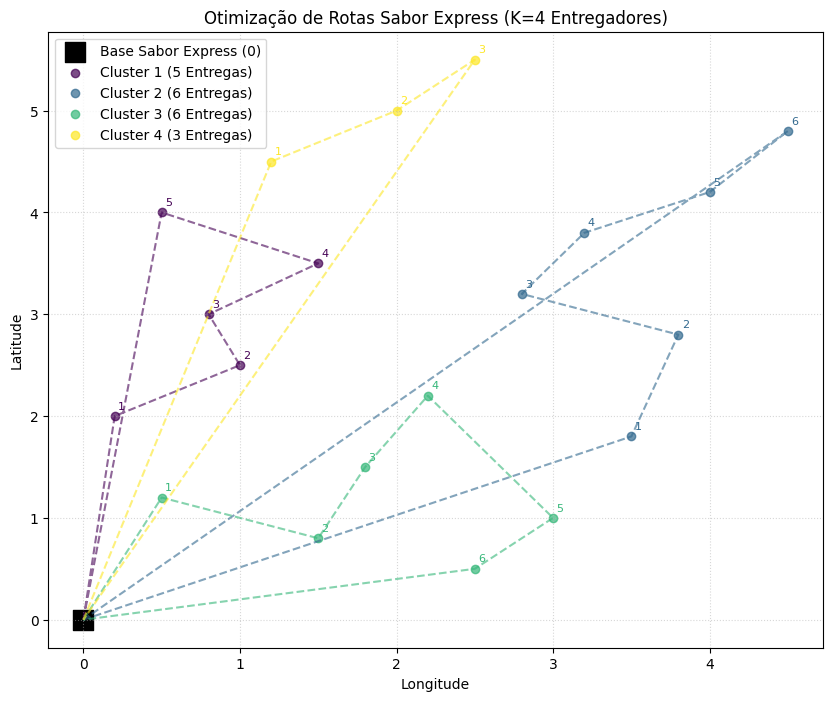


--- Resultados do Clustering e Roteamento ---
    ID  Lat  Lon  Cluster
3    3  2.0  0.2        0
6    6  2.5  1.0        0
8    8  3.0  0.8        0
10  10  3.5  1.5        0
12  12  4.0  0.5        0
11  11  1.8  3.5        1
13  13  3.2  2.8        1
15  15  2.8  3.8        1
18  18  4.2  4.0        1
20  20  4.8  4.5        1
17  17  3.8  3.2        1
7    7  1.0  3.0        2
1    1  1.2  0.5        2
5    5  0.5  2.5        2
2    2  0.8  1.5        2
4    4  1.5  1.8        2
9    9  2.2  2.2        2
14  14  4.5  1.2        3
16  16  5.0  2.0        3
19  19  5.5  2.5        3

Distância Total Otimizada (K=4): 45.53


In [1]:
# -*- coding: utf-8 -*-
"""
Otimização de Rotas para Sabor Express - Adaptado para Google Colab

Este script implementa a solução híbrida de otimização de rotas:
1. Agrupamento de entregas com K-Means.
2. Otimização da rota de cada cluster com a heurística Nearest Neighbor, utilizando a distância euclidiana como custo (simulando o A* em um grafo completo).
"""

# --- 0. Instalação e Importação de Bibliotecas ---
# As bibliotecas principais (pandas, numpy, scikit-learn, matplotlib) já estão instaladas no Colab.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from math import sqrt

# --- 1. Definição dos Dados (Simulados) ---

# Dados simulados de 20 entregas e a Base (ID 0)
data = {
    'ID': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'Type': ['Base', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery', 'Delivery'],
    'Lat': [0.0, 1.2, 0.8, 2.0, 1.5, 0.5, 2.5, 1.0, 3.0, 2.2, 3.5, 1.8, 4.0, 3.2, 4.5, 2.8, 5.0, 3.8, 4.2, 5.5, 4.8],
    'Lon': [0.0, 0.5, 1.5, 0.2, 1.8, 2.5, 1.0, 3.0, 0.8, 2.2, 1.5, 3.5, 0.5, 2.8, 1.2, 3.8, 2.0, 3.2, 4.0, 2.5, 4.5]
}
df = pd.DataFrame(data)

# --- 2. Funções de Suporte ---

def euclidean_distance(p1, p2):
    """Calcula a distância euclidiana entre dois pontos (Lat, Lon)."""
    return sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# --- 3. Implementação do Grafo e A* Simplificado ---

class Grafo:
    def __init__(self, points):
        # points é um dicionário {ID: (Lat, Lon)}
        self.points = points
        self.nodes = list(points.keys())
        self.adj = {node: {} for node in self.nodes}
        self._build_complete_graph()

    def _build_complete_graph(self):
        """Constrói um grafo completo onde o peso da aresta é a distância euclidiana."""
        for i in self.nodes:
            for j in self.nodes:
                if i != j:
                    dist = euclidean_distance(self.points[i], self.points[j])
                    self.adj[i][j] = dist

    def a_star_search(self, start_node, goal_node):
        """
        Simulação do A* para pathfinding. Em um grafo completo com pesos euclidianos,
        o caminho mais curto é a aresta direta.
        """
        if start_node == goal_node:
            return [start_node], 0.0

        # O custo é simplesmente a distância direta
        cost = self.adj[start_node].get(goal_node, float('inf'))
        return [start_node, goal_node], cost

# --- 4. Heurística TSP: Nearest Neighbor ---

def nearest_neighbor_tsp(graph, start_node, delivery_nodes):
    """
    Heurística do Vizinho Mais Próximo para resolver o TSP para um cluster.
    """
    unvisited = set(delivery_nodes)
    current_node = start_node
    route = [start_node]
    total_cost = 0.0

    while unvisited:
        nearest_neighbor = None
        min_cost = float('inf')

        for neighbor in unvisited:
            # O custo é obtido diretamente do grafo (que usa a distância euclidiana)
            cost = graph.adj[current_node].get(neighbor, float('inf'))
            if cost < min_cost:
                min_cost = cost
                nearest_neighbor = neighbor

        if nearest_neighbor is None:
            break

        unvisited.remove(nearest_neighbor)
        route.append(nearest_neighbor)
        total_cost += min_cost
        current_node = nearest_neighbor

    # Retornar à base
    cost_to_base = graph.adj[current_node].get(start_node, float('inf'))
    route.append(start_node)
    total_cost += cost_to_base

    return route, total_cost

# --- 5. Função Principal de Otimização ---

def optimize_routes(dataframe, num_clusters):
    """
    Executa o processo completo de otimização: Clustering + Otimização de Rota.
    """
    df = dataframe.copy()
    base_location = df[df['ID'] == 0][['Lat', 'Lon']].values[0]
    deliveries_df = df[df['Type'] == 'Delivery'].copy()
    delivery_points = deliveries_df[['Lat', 'Lon']].values

    # 5.1. K-Means Clustering
    print(f"--- 1. Agrupamento K-Means (K={num_clusters}) ---")
    # O parâmetro n_init='auto' é recomendado para versões recentes do scikit-learn
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
    deliveries_df['Cluster'] = kmeans.fit_predict(delivery_points)

    # 5.2. Construção do Grafo
    all_points = df.set_index('ID')[['Lat', 'Lon']].T.to_dict('list')
    all_points = {k: tuple(v) for k, v in all_points.items()}
    city_graph = Grafo(all_points)

    # 5.3. Otimização de Rota para Cada Cluster
    optimized_routes = {}
    total_distance_optimized = 0.0

    print("--- 2. Otimização de Rota (Nearest Neighbor + A*) ---")
    for cluster_id in range(num_clusters):
        cluster_deliveries = deliveries_df[deliveries_df['Cluster'] == cluster_id]
        cluster_delivery_ids = cluster_deliveries['ID'].tolist()

        if not cluster_delivery_ids:
            continue

        # Aplica a heurística TSP
        route_ids, route_cost = nearest_neighbor_tsp(city_graph, 0, cluster_delivery_ids)

        optimized_routes[cluster_id] = {
            'route': route_ids,
            'cost': route_cost,
            'deliveries': cluster_deliveries
        }
        total_distance_optimized += route_cost

        print(f"Rota {cluster_id+1} (Entregas: {len(cluster_delivery_ids)}):")
        print(f"  Sequência: {' -> '.join(map(str, route_ids))}")
        print(f"  Distância Total (Euclidiana): {route_cost:.2f}")

    print(f"\nDistância Total Otimizada (K={num_clusters}): {total_distance_optimized:.2f}")

    return deliveries_df, optimized_routes, total_distance_optimized, base_location, city_graph

# --- 6. Execução e Visualização ---

if __name__ == "__main__":
    NUM_DELIVERERS = 4 # K = 4 entregadores

    df_results, routes, total_dist, base_loc, city_graph = optimize_routes(df, NUM_DELIVERERS)

    # Geração da Visualização
    plt.figure(figsize=(10, 8))

    # Plotar a Base
    plt.scatter(base_loc[1], base_loc[0], marker='s', color='black', s=200, label='Base Sabor Express (0)')

    # Cores para os clusters
    # Usando plt.colormaps['viridis'] para evitar o MatplotlibDeprecationWarning
    colors = plt.colormaps['viridis'](np.linspace(0, 1, NUM_DELIVERERS))

    # Plotar as entregas e as rotas
    for cluster_id, route_data in routes.items():
        cluster_df = route_data['deliveries']
        route = route_data['route']

        # Plotar os pontos do cluster
        plt.scatter(cluster_df['Lon'], cluster_df['Lat'], color=colors[cluster_id], label=f'Cluster {cluster_id+1} ({len(cluster_df)} Entregas)', alpha=0.7)

        # Plotar a rota
        route_coords = [city_graph.points[node] for node in route]
        route_lats = [coord[0] for coord in route_coords]
        route_lons = [coord[1] for coord in route_coords]

        plt.plot(route_lons, route_lats, color=colors[cluster_id], linestyle='--', linewidth=1.5, alpha=0.6)

        # Adicionar anotações para a sequência da rota
        for i, node_id in enumerate(route[:-1]): # Exclui o retorno à base
            if node_id != 0:
                # Encontra a posição do ponto
                lat, lon = city_graph.points[node_id]
                # Adiciona a anotação da ordem de visita
                plt.annotate(f'{i}', (lon, lat),
                             textcoords="offset points", xytext=(5,5), ha='center', fontsize=8, color=colors[cluster_id])

    plt.title(f'Otimização de Rotas Sabor Express (K={NUM_DELIVERERS} Entregadores)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)

    # Exibir o gráfico no Colab
    plt.show()

    # Exibir o DataFrame de resultados para visualização no Colab
    print("\n--- Resultados do Clustering e Roteamento ---")
    print(df_results[['ID', 'Lat', 'Lon', 'Cluster']].sort_values(by='Cluster'))

    # Salvar o custo total para documentação
    print(f"\nDistância Total Otimizada (K={NUM_DELIVERERS}): {total_dist:.2f}")
